In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

sns.set_style("whitegrid")

In [2]:
customers = pd.read_csv("../data/processed/customers_clean.csv")
survey = pd.read_csv("../data/processed/survey_clean.csv")

In [3]:
customers.head()
survey.head()

,customer_id,nps_score,customer_effort_score,satisfaction_score,interaction_channel,complaint_flag,nps_category
0,1,6,3,3,web,0,Detractor
1,2,3,5,5,mobile_app,1,Detractor
2,3,10,1,4,call_center,0,Promoter
3,4,7,1,3,branch,0,Passive
4,5,4,1,2,mobile_app,0,Detractor


Le dataset churn Kaggle n’a pas la même clé que ton survey simulé.
Donc on va créer une jointure cohérente pour le projet.

Comme survey a customer_id de 1 à 1000, et que customers contient 10 000 lignes environ, on va prendre un sous-ensemble des clients pour faire une jointure simple.

In [4]:
customers = customers.copy().reset_index(drop=True)
customers["customer_id"] = np.arange(1, len(customers) + 1)
customers.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,customer_id
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,2
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,3
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,4
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,5


In [5]:
model_df = customers.merge(survey, on="customer_id", how="inner")
model_df.shape

(1000, 21)

In [6]:
model_df.head()
model_df.info()
model_df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RowNumber              1000 non-null   int64  
 1   CustomerId             1000 non-null   int64  
 2   Surname                1000 non-null   str    
 3   CreditScore            1000 non-null   int64  
 4   Geography              1000 non-null   str    
 5   Gender                 1000 non-null   str    
 6   Age                    1000 non-null   int64  
 7   Tenure                 1000 non-null   int64  
 8   Balance                1000 non-null   float64
 9   NumOfProducts          1000 non-null   int64  
 10  HasCrCard              1000 non-null   int64  
 11  IsActiveMember         1000 non-null   int64  
 12  EstimatedSalary        1000 non-null   float64
 13  Exited                 1000 non-null   int64  
 14  customer_id            1000 non-null   int64  
 15  nps_score       

RowNumber                0
CustomerId               0
Surname                  0
CreditScore              0
Geography                0
Gender                   0
Age                      0
Tenure                   0
Balance                  0
NumOfProducts            0
HasCrCard                0
IsActiveMember           0
EstimatedSalary          0
Exited                   0
customer_id              0
nps_score                0
customer_effort_score    0
satisfaction_score       0
interaction_channel      0
complaint_flag           0
nps_category             0
dtype: int64

In [7]:
def categorize_nps(score):
    if score >= 9:
        return "Promoter"
    elif score >= 7:
        return "Passive"
    else:
        return "Detractor"

model_df["nps_category"] = model_df["nps_score"].apply(categorize_nps)

In [8]:
model_df["low_satisfaction_flag"] = (model_df["satisfaction_score"] <= 2).astype(int)

In [9]:
model_df["high_effort_flag"] = (model_df["customer_effort_score"] >= 4).astype(int)

In [10]:
target = "Exited"

In [11]:
features = [
    "CreditScore",
    "Geography",
    "Gender",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary",
    "nps_score",
    "customer_effort_score",
    "satisfaction_score",
    "interaction_channel",
    "complaint_flag",
    "nps_category",
    "low_satisfaction_flag",
    "high_effort_flag"
]

In [12]:
X = model_df[features]
y = model_df[target]

In [13]:
categorical_features = [
    "Geography",
    "Gender",
    "interaction_channel",
    "nps_category"
]

numeric_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary",
    "nps_score",
    "customer_effort_score",
    "satisfaction_score",
    "complaint_flag",
    "low_satisfaction_flag",
    "high_effort_flag"
]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [16]:
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

log_reg_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [17]:
y_pred = log_reg_pipeline.predict(X_test)
y_proba = log_reg_pipeline.predict_proba(X_test)[:, 1]

In [18]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

Accuracy: 0.815
Precision: 0.6666666666666666
Recall: 0.1951219512195122
F1-score: 0.3018867924528302
ROC AUC: 0.7404509894155545


In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89       159
           1       0.67      0.20      0.30        41

    accuracy                           0.81       200
   macro avg       0.75      0.58      0.60       200
weighted avg       0.79      0.81      0.77       200



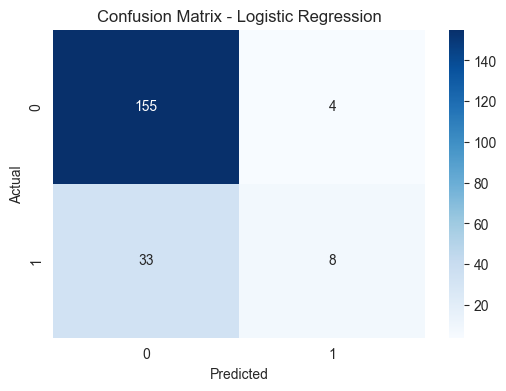

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

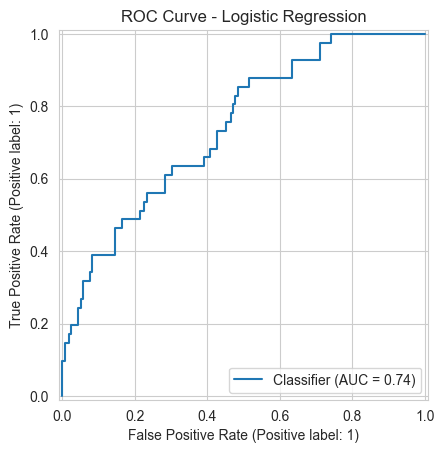

In [21]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve - Logistic Regression")
plt.show()

In [22]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [23]:
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

In [24]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_proba_rf))

Accuracy: 0.83
Precision: 0.8888888888888888
Recall: 0.1951219512195122
F1-score: 0.32
ROC AUC: 0.811934345758552


In [25]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf)
    ],
    "F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, y_proba),
        roc_auc_score(y_test, y_proba_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.815,0.666667,0.195122,0.301887,0.740451
1,Random Forest,0.830,0.888889,0.195122,0.320000,0.811934


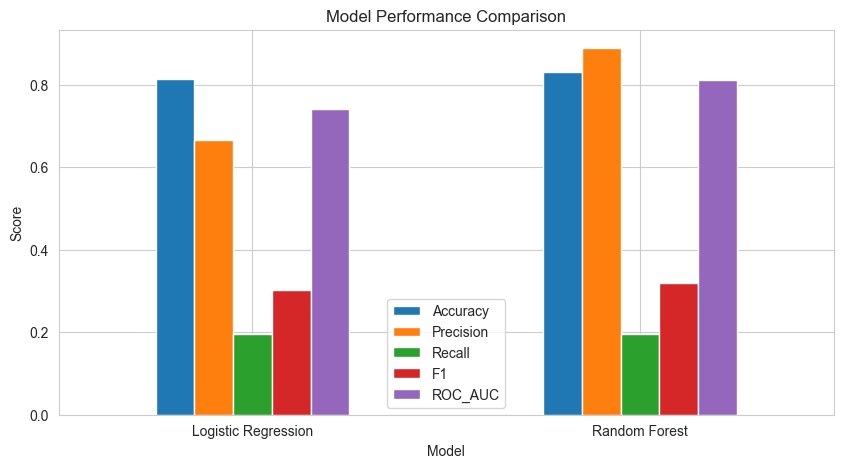

In [26]:
results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]].plot(
    kind="bar",
    figsize=(10, 5)
)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [27]:
rf_model = rf_pipeline.named_steps["model"]
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

importance_df.head(15)

,feature,importance
1,num__Age,0.214917
4,num__NumOfProducts,0.128234
7,num__EstimatedSalary,0.082068
0,num__CreditScore,0.080341
3,num__Balance,0.076054
6,num__IsActiveMember,0.071734
2,num__Tenure,0.055694
8,num__nps_score,0.042743
9,num__customer_effort_score,0.030360
10,num__satisfaction_score,0.029311


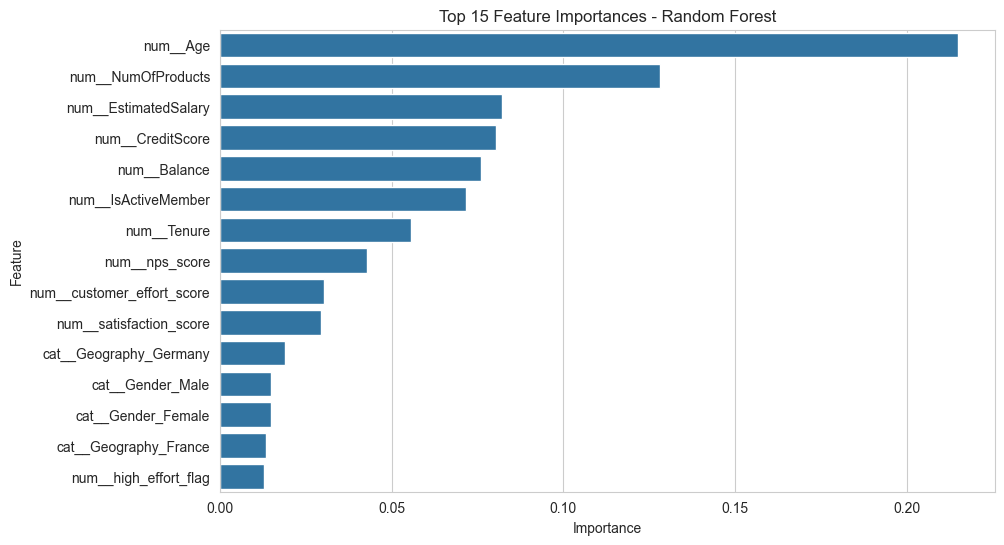

In [28]:
top_importance = importance_df.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_importance, x="importance", y="feature")
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Business interpretation

The churn model suggests that customer retention is driven by a combination of:

- customer engagement (`IsActiveMember`)
- relationship depth (`NumOfProducts`)
- customer experience metrics (`nps_score`, `satisfaction_score`, `customer_effort_score`)
- complaint exposure (`complaint_flag`)

This supports the idea that churn cannot be explained by transactional variables alone.  
Customer experience signals add business value and help identify at-risk customers earlier.

In [29]:
model_df["churn_risk_score"] = rf_pipeline.predict_proba(X)[:, 1]
model_df["predicted_churn"] = rf_pipeline.predict(X)

In [30]:
def risk_segment(score):
    if score >= 0.7:
        return "High risk"
    elif score >= 0.4:
        return "Medium risk"
    else:
        return "Low risk"

model_df["risk_segment"] = model_df["churn_risk_score"].apply(risk_segment)
model_df["risk_segment"].value_counts()

risk_segment
Low risk       831
Medium risk    104
High risk       65
Name: count, dtype: int64

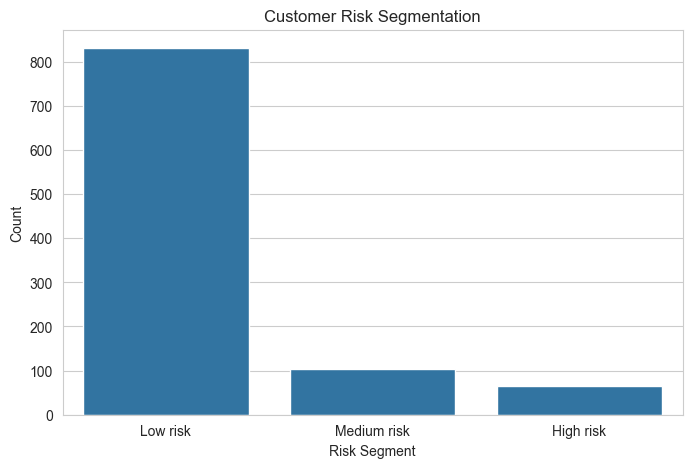

In [31]:
plt.figure(figsize=(8, 5))
sns.countplot(x="risk_segment", data=model_df, order=["Low risk", "Medium risk", "High risk"])
plt.title("Customer Risk Segmentation")
plt.xlabel("Risk Segment")
plt.ylabel("Count")
plt.show()

In [32]:
model_df.to_csv("../data/processed/churn_scored_customers.csv", index=False)
results.to_csv("../outputs/tables/model_comparison.csv", index=False)
importance_df.to_csv("../outputs/tables/feature_importance.csv", index=False)

In [33]:
import joblib

joblib.dump(rf_pipeline, "../models/churn_model.pkl")

['../models/churn_model.pkl']

## Key findings

This modeling step shows that churn can be predicted using both customer profile variables and customer experience indicators.

Main findings:
- customer experience metrics improve business understanding of churn risk
- engagement and product ownership remain strong churn drivers
- NPS, satisfaction and effort scores provide actionable retention signals
- the resulting churn score can support prioritization and customer journey improvement initiatives

This approach illustrates how customer analytics can help transform raw customer data into retention-focused decisions.